In [1]:
!pip install pydicom scikit-image matplotlib opencv-python imgaug


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models


In [4]:
# Set your dataset paths
train_dir = r"E:\results\TCIASplit\train"
val_dir = r"E:\results\TCIASplit\val"
test_dir = r"E:\results\TCIASplit\test"


In [5]:
import xml.etree.ElementTree as ET

def parse_xml_annotations(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Define namespace
    ns = {'lidc': 'http://www.nih.gov'}
    
    nodules = []
    
    reading_sessions = root.findall('lidc:readingSession', ns)
    print(f"Found {len(reading_sessions)} reading sessions.")
    
    for reading_session in reading_sessions:
        radiologist_id_node = reading_session.find('lidc:servicingRadiologistID', ns)
        radiologist_id = radiologist_id_node.text if radiologist_id_node is not None else "Unknown"
        
        unblinded_nodules = reading_session.findall('lidc:unblindedReadNodule', ns)
        print(f"Found {len(unblinded_nodules)} unblinded nodules for radiologist {radiologist_id}.")
        
        for unblinded_nodule in unblinded_nodules:
            nodule_id_node = unblinded_nodule.find('lidc:noduleID', ns)
            nodule_id = nodule_id_node.text if nodule_id_node is not None else "Unknown"
            
            # Get characteristics if available
            characteristics = {}
            chars_node = unblinded_nodule.find('lidc:characteristics', ns)
            if chars_node is not None:
                for char in chars_node:
                    characteristics[char.tag.replace(f"{{{ns['lidc']}}}", "")] = int(char.text)
            
            # Get ROI coordinates
            for roi in unblinded_nodule.findall('lidc:roi', ns):
                z_position_node = roi.find('lidc:imageZposition', ns)
                z_position = float(z_position_node.text.strip()) if z_position_node is not None else None
                
                inclusion_node = roi.find('lidc:inclusion', ns)
                inclusion = inclusion_node.text == 'TRUE' if inclusion_node is not None else None
                
                # Extract edge coordinates
                edge_coords = []
                for edge_map in roi.findall('lidc:edgeMap', ns):
                    x_node = edge_map.find('lidc:xCoord', ns)
                    y_node = edge_map.find('lidc:yCoord', ns)
                    if x_node is not None and y_node is not None:
                        edge_coords.append((int(x_node.text), int(y_node.text)))
                
                nodules.append({
                    'radiologistID': radiologist_id,
                    'noduleID': nodule_id,
                    'z_position': z_position,
                    'inclusion': inclusion,
                    'edge_coords': edge_coords,
                    'characteristics': characteristics
                })
    
    return nodules

xml_path = r"E:\results\TCIASplit\test\LIDC-IDRI-0011\01-01-2000-NA-NA-73568\3000559.000000-NA-23138\088.xml"
nodules = parse_xml_annotations(xml_path)

print(f"\nTotal nodules parsed: {len(nodules)}")
if nodules:
    print("\nFirst nodule example:")
    print(nodules[0])


Found 4 reading sessions.
Found 10 unblinded nodules for radiologist -1379024225.
Found 5 unblinded nodules for radiologist 274450807.
Found 16 unblinded nodules for radiologist -328702485.
Found 15 unblinded nodules for radiologist 2039481714.

Total nodules parsed: 99

First nodule example:
{'radiologistID': '-1379024225', 'noduleID': 'Nodule 007', 'z_position': -260.25, 'inclusion': True, 'edge_coords': [(109, 327), (108, 328), (107, 329), (106, 330), (106, 331), (106, 332), (106, 333), (106, 334), (107, 335), (108, 335), (109, 335), (110, 335), (111, 335), (112, 335), (113, 335), (114, 334), (114, 333), (114, 332), (114, 331), (114, 330), (113, 329), (112, 328), (111, 327), (110, 327), (109, 327)], 'characteristics': {'subtlety': 4, 'internalStructure': 1, 'calcification': 6, 'sphericity': 4, 'margin': 4, 'lobulation': 1, 'spiculation': 1, 'texture': 5, 'malignancy': 3}}


In [6]:
import os
import xml.etree.ElementTree as ET

def parse_xml_annotations(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    ns = {'lidc': 'http://www.nih.gov'}

    nodules = []

    reading_sessions = root.findall('lidc:readingSession', ns)

    for reading_session in reading_sessions:
        radiologist_id_node = reading_session.find('lidc:servicingRadiologistID', ns)
        radiologist_id = radiologist_id_node.text if radiologist_id_node is not None else "Unknown"

        unblinded_nodules = reading_session.findall('lidc:unblindedReadNodule', ns)

        for unblinded_nodule in unblinded_nodules:
            nodule_id_node = unblinded_nodule.find('lidc:noduleID', ns)
            nodule_id = nodule_id_node.text if nodule_id_node is not None else "Unknown"

            characteristics = {}
            chars_node = unblinded_nodule.find('lidc:characteristics', ns)
            if chars_node is not None:
                for char in chars_node:
                    characteristics[char.tag.replace(f"{{{ns['lidc']}}}", "")] = int(char.text)

            for roi in unblinded_nodule.findall('lidc:roi', ns):
                z_position_node = roi.find('lidc:imageZposition', ns)
                z_position = float(z_position_node.text.strip()) if z_position_node is not None else None

                inclusion_node = roi.find('lidc:inclusion', ns)
                inclusion = inclusion_node.text == 'TRUE' if inclusion_node is not None else None

                edge_coords = []
                for edge_map in roi.findall('lidc:edgeMap', ns):
                    x_node = edge_map.find('lidc:xCoord', ns)
                    y_node = edge_map.find('lidc:yCoord', ns)
                    if x_node is not None and y_node is not None:
                        edge_coords.append((int(x_node.text), int(y_node.text)))

                nodules.append({
                    'xml_path': xml_path,
                    'radiologistID': radiologist_id,
                    'noduleID': nodule_id,
                    'z_position': z_position,
                    'inclusion': inclusion,
                    'edge_coords': edge_coords,
                    'characteristics': characteristics
                })

    return nodules

def parse_all_xmls_in_directory(base_dirs):
    all_nodules = []

    for base_dir in base_dirs:
        print(f"Searching in {base_dir}...")
        for root_dir, _, files in os.walk(base_dir):
            for file in files:
                if file.lower().endswith(".xml"):
                    xml_path = os.path.join(root_dir, file)
                    nodules = parse_xml_annotations(xml_path)
                    if nodules:
                        all_nodules.extend(nodules)
    
    return all_nodules

# Set your dataset paths
train_dir = r"E:\results\TCIASplit\train"
val_dir = r"E:\results\TCIASplit\val"
test_dir = r"E:\results\TCIASplit\test"

# Parse all XMLs
all_nodules = parse_all_xmls_in_directory([train_dir, val_dir, test_dir])

print(f"\n✅ Total nodules found: {len(all_nodules)}")
if all_nodules:
    print("\nExample nodule:")
    print(all_nodules[0])


Searching in E:\results\TCIASplit\train...
Searching in E:\results\TCIASplit\val...
Searching in E:\results\TCIASplit\test...

✅ Total nodules found: 50282

Example nodule:
{'xml_path': 'E:\\results\\TCIASplit\\train\\LIDC-IDRI-0001\\01-01-2000-NA-NA-30178\\3000566.000000-NA-03192\\069.xml', 'radiologistID': '540461523', 'noduleID': 'Nodule 001', 'z_position': -125.0, 'inclusion': True, 'edge_coords': [(312, 355), (311, 356), (310, 357), (309, 357), (308, 358), (308, 359), (308, 360), (307, 360), (306, 361), (306, 362), (305, 363), (304, 364), (303, 365), (303, 366), (302, 367), (302, 368), (302, 369), (301, 370), (301, 371), (300, 371), (299, 372), (299, 373), (299, 374), (299, 375), (299, 376), (300, 377), (301, 378), (302, 379), (303, 379), (304, 379), (305, 379), (306, 379), (307, 378), (308, 377), (308, 376), (309, 375), (310, 375), (311, 375), (312, 375), (313, 375), (314, 375), (315, 375), (316, 375), (317, 375), (318, 375), (319, 375), (320, 374), (321, 373), (322, 372), (322, 

Parsing XML annotations...
Searching in E:\results\TCIASplit\train...
Searching in E:\results\TCIASplit\val...
Searching in E:\results\TCIASplit\test...

✅ Total nodules found: 50282

Example nodule:
{'xml_path': 'E:\\results\\TCIASplit\\train\\LIDC-IDRI-0001\\01-01-2000-NA-NA-30178\\3000566.000000-NA-03192\\069.xml', 'radiologistID': '540461523', 'noduleID': 'Nodule 001', 'z_position': -125.0, 'inclusion': True, 'edge_coords': [(312, 355), (311, 356), (310, 357), (309, 357), (308, 358), (308, 359), (308, 360), (307, 360), (306, 361), (306, 362), (305, 363), (304, 364), (303, 365), (303, 366), (302, 367), (302, 368), (302, 369), (301, 370), (301, 371), (300, 371), (299, 372), (299, 373), (299, 374), (299, 375), (299, 376), (300, 377), (301, 378), (302, 379), (303, 379), (304, 379), (305, 379), (306, 379), (307, 378), (308, 377), (308, 376), (309, 375), (310, 375), (311, 375), (312, 375), (313, 375), (314, 375), (315, 375), (316, 375), (317, 375), (318, 375), (319, 375), (320, 374), (32

100%|██████████| 488532/488532 [15:08<00:00, 537.61it/s]



✅ Indexed 487394 DICOM files


Matching nodules: 100%|██████████| 50282/50282 [00:01<00:00, 39531.89it/s]



✅ Successfully matched 50282/50282 nodules

✅ Dataset saved to 'E:\results\TCIASplit\nodule_dataset.csv'

Sample nodule:
{'nodule_id': 'Nodule 001', 'dicom_path': 'E:\\results\\TCIASplit\\test\\LIDC-IDRI-0816\\01-01-2000-NA-CT LUNG SCREEN-63949\\NA-17512\\1-089.dcm', 'xml_path': 'E:\\results\\TCIASplit\\train\\LIDC-IDRI-0001\\01-01-2000-NA-NA-30178\\3000566.000000-NA-03192\\069.xml', 'z_position': -125.0, 'edge_coords': [(312, 355), (311, 356), (310, 357), (309, 357), (308, 358), (308, 359), (308, 360), (307, 360), (306, 361), (306, 362), (305, 363), (304, 364), (303, 365), (303, 366), (302, 367), (302, 368), (302, 369), (301, 370), (301, 371), (300, 371), (299, 372), (299, 373), (299, 374), (299, 375), (299, 376), (300, 377), (301, 378), (302, 379), (303, 379), (304, 379), (305, 379), (306, 379), (307, 378), (308, 377), (308, 376), (309, 375), (310, 375), (311, 375), (312, 375), (313, 375), (314, 375), (315, 375), (316, 375), (317, 375), (318, 375), (319, 375), (320, 374), (321, 373)

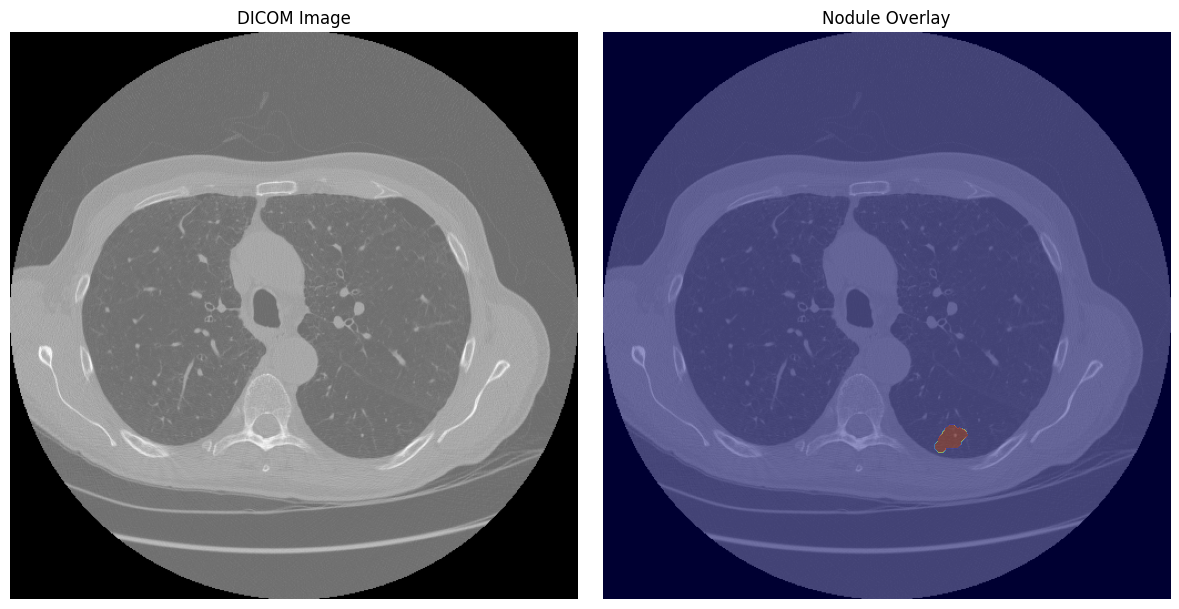

In [8]:
import os
import xml.etree.ElementTree as ET
import pydicom
import numpy as np
from skimage.draw import polygon
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from scipy.spatial import KDTree
from tqdm import tqdm

def parse_xml_annotations(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    ns = {'lidc': 'http://www.nih.gov'} if root.tag.startswith('{') else {}

    nodules = []
    reading_sessions = root.findall('readingSession') or root.findall('lidc:readingSession', ns)

    for reading_session in reading_sessions:
        radiologist_id_node = (reading_session.find('servicingRadiologistID') or 
                               reading_session.find('lidc:servicingRadiologistID', ns))
        radiologist_id = radiologist_id_node.text if radiologist_id_node is not None else "Unknown"

        unblinded_nodules = (reading_session.findall('unblindedReadNodule') or 
                             reading_session.findall('lidc:unblindedReadNodule', ns))

        for unblinded_nodule in unblinded_nodules:
            nodule_id_node = (unblinded_nodule.find('noduleID') or 
                              unblinded_nodule.find('lidc:noduleID', ns))
            nodule_id = nodule_id_node.text if nodule_id_node is not None else "Unknown"

            characteristics = {}
            chars_node = (unblinded_nodule.find('characteristics') or 
                          unblinded_nodule.find('lidc:characteristics', ns))
            if chars_node is not None:
                for char in chars_node:
                    char_name = char.tag.split('}')[-1] if '}' in char.tag else char.tag
                    characteristics[char_name] = int(char.text)

            rois = unblinded_nodule.findall('roi') or unblinded_nodule.findall('lidc:roi', ns)
            for roi in rois:
                z_position_node = roi.find('imageZposition') or roi.find('lidc:imageZposition', ns)
                z_position = float(z_position_node.text.strip()) if z_position_node is not None else None

                inclusion_node = roi.find('inclusion') or roi.find('lidc:inclusion', ns)
                inclusion = inclusion_node.text == 'TRUE' if inclusion_node is not None else None

                edge_coords = []
                edge_maps = roi.findall('edgeMap') or roi.findall('lidc:edgeMap', ns)
                for edge_map in edge_maps:
                    x_node = edge_map.find('xCoord') or edge_map.find('lidc:xCoord', ns)
                    y_node = edge_map.find('yCoord') or edge_map.find('lidc:yCoord', ns)
                    if x_node is not None and y_node is not None:
                        edge_coords.append((int(x_node.text), int(y_node.text)))

                nodules.append({
                    'xml_path': xml_path,
                    'radiologistID': radiologist_id,
                    'noduleID': nodule_id,
                    'z_position': z_position,
                    'inclusion': inclusion,
                    'edge_coords': edge_coords,
                    'characteristics': characteristics
                })

    return nodules

def parse_all_xmls_in_directory(base_dirs):
    all_nodules = []
    for base_dir in base_dirs:
        print(f"Searching in {base_dir}...")
        for root_dir, _, files in os.walk(base_dir):
            for file in files:
                if file.lower().endswith(".xml"):
                    xml_path = os.path.join(root_dir, file)
                    try:
                        nodules = parse_xml_annotations(xml_path)
                        if nodules:
                            all_nodules.extend(nodules)
                    except Exception as e:
                        print(f"Error parsing {xml_path}: {str(e)}")
    return all_nodules

def index_all_dicoms(base_dirs):
    print("\nIndexing DICOM files...")
    dicom_paths = []
    for base_dir in base_dirs:
        for root, _, files in os.walk(base_dir):
            for file in files:
                if file.lower().endswith('.dcm'):
                    dicom_paths.append(os.path.join(root, file))
    
    dicom_info = []

    def read_dicom_z(dicom_path):
        try:
            ds = pydicom.dcmread(dicom_path, stop_before_pixels=True)
            if hasattr(ds, 'ImagePositionPatient') and len(ds.ImagePositionPatient) >= 3:
                return (float(ds.ImagePositionPatient[2]), dicom_path)
        except:
            pass
        return None

    with ThreadPoolExecutor(max_workers=16) as executor:
        results = list(tqdm(executor.map(read_dicom_z, dicom_paths), total=len(dicom_paths)))

    results = [r for r in results if r is not None]

    if results:
        z_positions, paths = zip(*results)
        tree = KDTree(np.array(z_positions).reshape(-1, 1))
        return tree, z_positions, paths
    else:
        raise RuntimeError("No valid DICOM files found.")

def create_nodule_dataset(all_nodules, kd_tree, z_positions, paths):
    dataset = []
    
    for nodule in tqdm(all_nodules, desc="Matching nodules"):
        target_z = nodule['z_position']
        if target_z is None:
            continue
        
        dist, idx = kd_tree.query([[target_z]], k=1)
        matched_path = paths[idx[0]]

        dataset.append({
            'nodule_id': nodule['noduleID'],
            'dicom_path': matched_path,
            'xml_path': nodule['xml_path'],
            'z_position': nodule['z_position'],
            'edge_coords': nodule['edge_coords'],
            'characteristics': nodule['characteristics']
        })
        
    return dataset

def visualize_nodule(dicom_path, edge_coords):
    try:
        dicom = pydicom.dcmread(dicom_path)
        image = dicom.pixel_array
        
        mask = np.zeros_like(image, dtype=np.uint8)
        if len(edge_coords) > 2:
            x_coords = [x for x, y in edge_coords]
            y_coords = [y for x, y in edge_coords]
            rr, cc = polygon(y_coords, x_coords, image.shape)
            mask[rr, cc] = 1

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title("DICOM Image")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(image, cmap='gray')
        plt.imshow(mask, alpha=0.4, cmap='jet')
        plt.title("Nodule Overlay")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error visualizing {dicom_path}: {str(e)}")

# Main script
train_dir = r"E:\results\TCIASplit\train"
val_dir = r"E:\results\TCIASplit\val"
test_dir = r"E:\results\TCIASplit\test"

print("Parsing XML annotations...")
all_nodules = parse_all_xmls_in_directory([train_dir, val_dir, test_dir])
print(f"\n✅ Total nodules found: {len(all_nodules)}")

if all_nodules:
    print("\nExample nodule:")
    print(all_nodules[0])

# Index DICOMs
kd_tree, z_positions, paths = index_all_dicoms([train_dir, val_dir, test_dir])
print(f"\n✅ Indexed {len(paths)} DICOM files")

# Create dataset
nodule_dataset = create_nodule_dataset(all_nodules, kd_tree, z_positions, paths)
print(f"\n✅ Successfully matched {len(nodule_dataset)}/{len(all_nodules)} nodules")

# Save the dataset
df = pd.DataFrame(nodule_dataset)
output_path = os.path.join(os.path.dirname(train_dir), 'nodule_dataset.csv')
df.to_csv(output_path, index=False)
print(f"\n✅ Dataset saved to '{output_path}'")

# Visualize a sample
if nodule_dataset:
    sample = nodule_dataset[0]
    print("\nSample nodule:")
    print(sample)
    visualize_nodule(sample['dicom_path'], sample['edge_coords'])


In [10]:
pip install ultralytics

  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import os
import pandas as pd
import pydicom
import cv2
from sklearn.model_selection import train_test_split
import yaml
from tqdm import tqdm
from datetime import datetime

# ========================
# CONFIGURATION
# ========================
BASE_DIR = r"E:\results\TCIASplit"
CSV_PATH = os.path.join(BASE_DIR, "nodule_dataset.csv")
YOLO_DIR = os.path.join(BASE_DIR, "yolo_dataset")
TEST_SIZE = 0.2
RANDOM_STATE = 42

# ========================
# SETUP
# ========================
def setup_directories():
    """Create YOLO dataset directory structure with visual feedback"""
    print("\n📂 CREATING DIRECTORY STRUCTURE")
    print("━"*50)
    
    dirs = [
        ("Training Images", os.path.join(YOLO_DIR, "images", "train")),
        ("Validation Images", os.path.join(YOLO_DIR, "images", "val")),
        ("Training Labels", os.path.join(YOLO_DIR, "labels", "train")),
        ("Validation Labels", os.path.join(YOLO_DIR, "labels", "val"))
    ]
    
    for name, path in dirs:
        os.makedirs(path, exist_ok=True)
        print(f"✔ {name.ljust(20)} → {path}")
    
    print("✓ Directory structure created successfully\n")
    return [d[1] for d in dirs]

# ========================
# DICOM TO YOLO CONVERSION
# ========================
def dicom_to_yolo(row, output_img_dir, output_label_dir):
    """Convert DICOM file to YOLO format with detailed error handling"""
    try:
        # Read and convert DICOM
        dicom_path = row['dicom_path']
        ds = pydicom.dcmread(dicom_path)
        img = ds.pixel_array
        
        # Save as PNG
        img_name = os.path.basename(dicom_path).replace('.dcm', '.png')
        img_path = os.path.join(output_img_dir, img_name)
        cv2.imwrite(img_path, img)
        
        # Process annotations
        edge_coords = eval(row['edge_coords']) if isinstance(row['edge_coords'], str) else row['edge_coords']
        height, width = img.shape
        
        yolo_lines = []
        if edge_coords:
            x_coords = [x for x,_ in edge_coords]
            y_coords = [y for _,y in edge_coords]
            
            # Convert to YOLO format
            x_center = (min(x_coords) + max(x_coords)) / 2 / width
            y_center = (min(y_coords) + max(y_coords)) / 2 / height
            box_width = (max(x_coords) - min(x_coords)) / width
            box_height = (max(y_coords) - min(y_coords)) / height
            
            yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}")
        
        # Save label file
        label_path = os.path.join(output_label_dir, img_name.replace('.png', '.txt'))
        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_lines))
            
        return True, ""
    
    except Exception as e:
        return False, f"{os.path.basename(dicom_path)}: {str(e)}"

# ========================
# PROGRESS TRACKING
# ========================
class ProgressTracker:
    def __init__(self, dataset_type):
        self.dataset_type = dataset_type
        self.success = 0
        self.errors = []
        self.start_time = datetime.now()
        
    def update(self, success, error_msg=""):
        if success:
            self.success += 1
        else:
            self.errors.append(error_msg)
    
    def print_summary(self):
        duration = (datetime.now() - self.start_time).total_seconds()
        print(f"\n{'✅' if not self.errors else '⚠️'} {self.dataset_type.upper()} SET COMPLETE")
        print("━"*50)
        print(f"  Processed: {self.success + len(self.errors)} total")
        print(f"  Successful: {self.success:>7}")
        print(f"  Failed:     {len(self.errors):>7}")
        print(f"  Duration:   {duration:.2f}s")
        
        if self.errors:
            print("\nTOP ERRORS:")
            for error in self.errors[:3]:
                print(f"  × {error}")
            if len(self.errors) > 3:
                print(f"  (...{len(self.errors)-3} more errors)")

# ========================
# MAIN PROCESSING
# ========================
def process_dataset(df, output_img_dir, output_label_dir, dataset_type):
    """Process dataset with beautiful progress tracking"""
    tracker = ProgressTracker(dataset_type)
    
    print(f"\n🔍 PROCESSING {dataset_type.upper()} SET ({len(df)} samples)")
    print("━"*50)
    
    with tqdm(df.iterrows(), total=len(df), unit="img") as pbar:
        for _, row in pbar:
            success, error_msg = dicom_to_yolo(row, output_img_dir, output_label_dir)
            tracker.update(success, error_msg)
            pbar.set_postfix({
                'success': tracker.success,
                'errors': len(tracker.errors)
            })
    
    tracker.print_summary()
    return tracker

# ========================
# MAIN EXECUTION
# ========================
def main():
    print("\n" + "="*50)
    print("🚀 STARTING YOLO DATASET PREPARATION")
    print("="*50 + "\n")
    
    # Setup directories
    train_img_dir, val_img_dir, train_label_dir, val_label_dir = setup_directories()
    
    # Load dataset
    print("\n📊 LOADING DATASET")
    print("━"*50)
    df = pd.read_csv(CSV_PATH)
    print(f"✔ Loaded {len(df)} records from:\n  {CSV_PATH}")
    
    # Split dataset
    train_df, val_df = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    print("\n🔀 DATASET SPLIT")
    print("━"*50)
    print(f"  Training:    {len(train_df):>7} samples")
    print(f"  Validation:  {len(val_df):>7} samples")
    
    # Process datasets
    train_tracker = process_dataset(train_df, train_img_dir, train_label_dir, "training")
    val_tracker = process_dataset(val_df, val_img_dir, val_label_dir, "validation")
    
    # Create YOLO config
    print("\n⚙️  GENERATING YOLO CONFIG")
    print("━"*50)
    data = {
        'train': os.path.join(YOLO_DIR, "images", "train"),
        'val': os.path.join(YOLO_DIR, "images", "val"),
        'names': ['nodule'],
        'nc': 1
    }
    
    yaml_path = os.path.join(YOLO_DIR, "data.yaml")
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f)
    print(f"✔ Config saved to:\n  {yaml_path}")
    
    # Final summary
    total_time = (datetime.now() - start_time).total_seconds()
    print("\n" + "="*50)
    print(f"🎉 PROCESSING COMPLETE! (Total: {total_time:.2f}s)")
    print("="*50)
    print(f"  Total processed: {len(df)}")
    print(f"  Total success:   {train_tracker.success + val_tracker.success}")
    print(f"  Total errors:    {len(train_tracker.errors) + len(val_tracker.errors)}")
    print("\n✨ Dataset ready for YOLO training! ✨")

if __name__ == "__main__":
    start_time = datetime.now()
    main()


🚀 STARTING YOLO DATASET PREPARATION


📂 CREATING DIRECTORY STRUCTURE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✔ Training Images      → E:\results\TCIASplit\yolo_dataset\images\train
✔ Validation Images    → E:\results\TCIASplit\yolo_dataset\images\val
✔ Training Labels      → E:\results\TCIASplit\yolo_dataset\labels\train
✔ Validation Labels    → E:\results\TCIASplit\yolo_dataset\labels\val
✓ Directory structure created successfully


📊 LOADING DATASET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✔ Loaded 289296 records from:
  E:\results\TCIASplit\nodule_dataset.csv

🔀 DATASET SPLIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training:     231436 samples
  Validation:    57860 samples

🔍 PROCESSING TRAINING SET (231436 samples)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


100%|██████████| 231436/231436 [4:33:11<00:00, 14.12img/s, success=231436, errors=0]    



✅ TRAINING SET COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processed: 231436 total
  Successful:  231436
  Failed:           0
  Duration:   16391.85s

🔍 PROCESSING VALIDATION SET (57860 samples)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


100%|██████████| 57860/57860 [56:33<00:00, 17.05img/s, success=57860, errors=0]   



✅ VALIDATION SET COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processed: 57860 total
  Successful:   57860
  Failed:           0
  Duration:   3393.09s

⚙️  GENERATING YOLO CONFIG
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✔ Config saved to:
  E:\results\TCIASplit\yolo_dataset\data.yaml

🎉 PROCESSING COMPLETE! (Total: 19785.47s)
  Total processed: 289296
  Total success:   289296
  Total errors:    0

✨ Dataset ready for YOLO training! ✨


In [9]:
def verify_annotations():
    import matplotlib.pyplot as plt
    from PIL import Image, ImageDraw
    
    # Load sample
    img_path = os.path.join(YOLO_DIR, "images", "train", os.listdir(os.path.join(YOLO_DIR, "images", "train"))[0])
    label_path = img_path.replace("images", "labels").replace(".png", ".txt")
    
    # Visualize
    img = Image.open(img_path)
    draw = ImageDraw.Draw(img)
    w, h = img.size
    
    with open(label_path) as f:
        for line in f:
            class_id, xc, yc, bw, bh = map(float, line.split())
            # Convert to pixel coordinates
            x1 = (xc - bw/2) * w
            y1 = (yc - bh/2) * h
            x2 = (xc + bw/2) * w
            y2 = (yc + bh/2) * h
            draw.rectangle([x1,y1,x2,y2], outline="red", width=3)
    
    plt.figure(figsize=(12,12))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print(f"Annotation values: {open(label_path).read()}")

verify_annotations()

<Figure size 1200x1200 with 1 Axes>

Annotation values: 0 0.039062 0.058594 0.039062 0.039062


In [3]:
from ultralytics import YOLO
import os

# Configuration
yolo_data = os.path.join(r"E:\results\TCIASplit", "yolo_dataset", "data.yaml")

def train_lung_nodule_detector():
    # Load model
    model = YOLO('yolov8n.pt')  # Starting from pretrained nano model
    
    # Training parameters
    train_args = {
        'data': yolo_data,
        'epochs': 20,
        'imgsz': 256,           # Reduced image size for CPU training
        'batch': 8,              # Batch size adjusted for CPU memory
        'device': 'cpu',         # Explicit CPU training
        'workers': 2,            # Conservative for CPU stability
        'patience': 15,          # Slightly increased patience
        'name': 'lung_nodule_optimized_v2',
        'exist_ok': True,        # Allow overwriting existing runs
        
        # Optimization parameters
        'lr0': 0.001,            # Lower initial learning rate
        'optimizer': 'Adam',     # Adam typically works better than SGD for CPU
        'weight_decay': 0.0001,  # Reduced regularization
        'warmup_epochs': 5,      # Gradual learning rate warmup
        'warmup_momentum': 0.8,  # Conservative momentum during warmup
        'warmup_bias_lr': 0.1,  # Bias layer learning rate
        
        # Data augmentation (reduced for medical imaging)
        'hsv_h': 0.01,          # Minimal hue variation
        'hsv_s': 0.3,           # Reduced saturation variation
        'hsv_v': 0.2,           # Reduced value variation
        'fliplr': 0.2,           # Lower flip probability
        'degrees': 0.0,         # No rotation for medical images
        'translate': 0.05,       # Minimal translation
        'scale': 0.2,            # Reduced scaling
        'mosaic': 0.0,          # Disabled mosaic
        'mixup': 0.0,           # Disabled mixup
        'copy_paste': 0.0,      # Disabled copy-paste
        'erasing': 0.2,         # Reduced random erasing
        
        # Loss components
        'box': 3.0,             # Reduced box loss weight
        'cls': 0.2,             # Reduced cls loss weight (single class)
        'dfl': 0.8,             # Adjusted distribution focal loss
        'close_mosaic': 0,      # No mosaic to disable
        
        # Validation settings
        'val': True,            # Enable validation
        'save_json': False,     # Disable JSON output unless needed
        'plots': True,          # Enable plotting
        'save_period': 10,     # Save every 10 epochs
    }
    
    # Start training
    results = model.train(**train_args)
    
    # Export model to ONNX for potential deployment
    model.export(format='onnx', imgsz=256, simplify=True)
    
    return results

if __name__ == '__main__':
    train_lung_nodule_detector()

Ultralytics 8.3.119  Python-3.9.21 torch-2.7.0+cpu CPU (11th Gen Intel Core(TM) i5-11300H 3.10GHz)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=E:\results\TCIASplit\yolo_dataset\data.yaml, epochs=20, time=None, patience=15, batch=8, imgsz=256, save=True, save_period=10, cache=False, device=cpu, workers=2, project=None, name=lung_nodule_optimized_v2, exist_ok=True, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

train: Scanning E:\results\TCIASplit\yolo_dataset\labels\train.cache... 1897 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1897/1897 [00:00<?, ?it/s]

val: Fast image access  (ping: 0.10.0 ms, read: 1110.1634.9 MB/s, size: 184.1 KB)



C:\Users\maram\anaconda3\envs\efficientnet_env\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning E:\results\TCIASplit\yolo_dataset\labels\val.cache... 1491 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1491/1491 [00:00<?, ?it/s]
C:\Users\maram\anaconda3\envs\efficientnet_env\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Plotting labels to runs\detect\lung_nodule_optimized_v2\labels.jpg... 
optimizer: Adam(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0001), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 256 train, 256 val
Using 0 dataloader workers
Logging results to runs\detect\lung_nodule_optimized_v2
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1491       1491      0.995      0.993      0.995       0.62



20 epochs completed in 0.655 hours.
Optimizer stripped from runs\detect\lung_nodule_optimized_v2\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\lung_nodule_optimized_v2\weights\best.pt, 6.2MB

Validating runs\detect\lung_nodule_optimized_v2\weights\best.pt...
Ultralytics 8.3.119  Python-3.9.21 torch-2.7.0+cpu CPU (11th Gen Intel Core(TM) i5-11300H 3.10GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 94/94 [00:20<00:00,  4.58it/s]


                   all       1491       1491      0.993      0.993      0.994      0.839
Speed: 0.2ms preprocess, 10.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs\detect\lung_nodule_optimized_v2
Ultralytics 8.3.119  Python-3.9.21 torch-2.7.0+cpu CPU (11th Gen Intel Core(TM) i5-11300H 3.10GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs\detect\lung_nodule_optimized_v2\weights\best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 5, 1344) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.46', 'onnxruntime'] not found, attempting AutoUpdate...
   ---------------------------------------- 14.5/14.5 MB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 12.3/12.3 MB 1.5 MB/s eta 0:00:00

requirements: AutoUpdate success  31.9s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim>=0.1.46', 'onnxruntime']
WARNING requirements: Restart runtim

ModuleNotFoundError: No module named 'onnx'

In [ ]:
from ultralytics import YOLO
import cv2
import os
import glob
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support

# Load your best model
model = YOLO('runs/detect/lung_nodule_optimized_v2/weights/best.pt')

def compute_iou(box1, box2):
    """Calculate IoU between two boxes (x1, y1, x2, y2)."""
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Calculate intersection coordinates
    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0

def evaluate_detections(pred_boxes, gt_boxes, iou_threshold=0.5):
    """Evaluate predictions against ground truth."""
    # Handle edge cases
    if not gt_boxes:
        if not pred_boxes:
            return 1.0, 1.0, 1.0, 1.0  # Perfect score if nothing to predict and nothing predicted
        else:
            return 0.0, 1.0, 0.0, 0.0  # All predictions are FP
    
    if not pred_boxes:
        return 1.0, 0.0, 0.0, 0.0  # All GT are FN
    
    # Initialize variables
    matches = []
    pred_matched = set()
    gt_matched = set()
    ious = []
    
    # Find best matches between predictions and ground truth
    for i, pred in enumerate(pred_boxes):
        best_iou = 0
        best_gt_idx = -1
        for j, gt in enumerate(gt_boxes):
            if j in gt_matched:
                continue
            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j
        
        if best_iou >= iou_threshold and best_gt_idx >= 0:
            matches.append((i, best_gt_idx, best_iou))
            pred_matched.add(i)
            gt_matched.add(best_gt_idx)
            ious.append(best_iou)
    
    # Calculate metrics
    tp = len(matches)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    mean_iou = np.mean(ious) if ious else 0
    
    return precision, recall, f1, mean_iou

def enhance_image(image_path):
    """Preprocess image for better nodule visibility using CLAHE."""
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {image_path}")
    
    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_enhanced = clahe.apply(img)
    
    # Convert to 3-channel if needed
    if len(img_enhanced.shape) == 2:
        img_enhanced = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2BGR)
    
    # Save temporary enhanced image
    temp_path = 'temp_enhanced.png'
    cv2.imwrite(temp_path, img_enhanced)
    
    return temp_path

def load_ground_truth(label_path, img_width=256, img_height=256):
    """Load ground truth boxes from YOLO format label file."""
    gt_boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            labels = f.readlines()
        
        for line in labels:
            parts = line.strip().split()
            if len(parts) >= 5:
                # Convert from YOLO format (normalized cx,cy,w,h) to absolute coordinates (x1,y1,x2,y2)
                x_center = float(parts[1]) * img_width
                y_center = float(parts[2]) * img_height
                width = float(parts[3]) * img_width
                height = float(parts[4]) * img_height
                
                x1 = x_center - width / 2
                y1 = y_center - height / 2
                x2 = x_center + width / 2
                y2 = y_center + height / 2
                
                gt_boxes.append([x1, y1, x2, y2])
    
    return gt_boxes

def predict_and_visualize(image_path):
    """Run prediction and visualization pipeline for a single image."""
    image_path = Path(image_path)
    
    # Verify image exists
    if not image_path.exists():
        available_images = list(Path('E:/results/TCIASplit/yolo_dataset/images/val').glob('*.*'))
        print(f"Image not found. Available images in validation set:")
        for img in available_images[:5]:
            print(f"  - {img}")
        raise FileNotFoundError(f"Image file not found: {image_path}")
    
    # Load ground truth
    label_path = image_path.parent.parent / 'labels' / 'val' / f"{image_path.stem}.txt"
    gt_boxes = load_ground_truth(label_path)
    print(f"Label file {label_path}: {len(gt_boxes)} nodules")
    
    # Enhance image
    try:
        enhanced_path = enhance_image(image_path)
    except Exception as e:
        print(f"Image enhancement failed: {e}")
        enhanced_path = str(image_path)
    
    # Run prediction
    results = model.predict(
        enhanced_path,
        imgsz=256,
        conf=0.15,  # Adjusted confidence threshold
        iou=0.45,   # Adjusted IoU threshold
        save=True,
        save_txt=True,
        save_conf=True
    )
    
    # Extract predicted boxes
    pred_boxes = []
    confidences = []
    for r in results:
        if r.boxes is not None:
            for box, conf in zip(r.boxes.xyxy, r.boxes.conf):
                x1, y1, x2, y2 = map(float, box)
                pred_boxes.append([x1, y1, x2, y2])
                confidences.append(float(conf))
    
    print(f"Predicted {len(pred_boxes)} nodules")
    
    # Calculate metrics
    precision, recall, f1, mean_iou = evaluate_detections(pred_boxes, gt_boxes)
    print(f"\nAccuracy Metrics for {image_path.name}:")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1 Score: {f1:.3f}")
    print(f"  Mean IoU: {mean_iou:.3f}")
    
    # Visualization
    for r in results:
        # Create annotated image
        im_array = r.plot(line_width=2, font_size=0.8)
        
        # Convert to grayscale then back to color for consistent display
        im_gray = cv2.cvtColor(im_array, cv2.COLOR_BGR2GRAY)
        im_color = cv2.cvtColor(im_gray, cv2.COLOR_GRAY2BGR)
        
        # Add ground truth boxes in green
        for gt_box in gt_boxes:
            x1, y1, x2, y2 = map(int, gt_box)
            cv2.rectangle(im_color, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(im_color, "GT", (x1, y1-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        
        # Add predicted boxes in red with confidence
        for box, conf in zip(pred_boxes, confidences):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(im_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(im_color, f"{conf:.2f}", (x1, y1-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
        
        # Resize for better viewing
        im_display = cv2.resize(im_color, (1024, 1024), 
                             interpolation=cv2.INTER_LINEAR)
        
        # Show and save results
        cv2.imshow('Detection Results (Green=GT, Red=Pred)', im_display)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        
        output_path = f'output_{image_path.stem}.jpg'
        cv2.imwrite(output_path, im_color, [int(cv2.IMWRITE_JPEG_QUALITY), 100])
        print(f"\nVisualization saved to: {output_path}")
    
    return results, precision, recall, f1, mean_iou

def main():
    # Find images with nodules in validation set
    val_dir = Path('E:/results/TCIASplit/yolo_dataset/images/val')
    label_dir = val_dir.parent.parent / 'labels' / 'val'
    
    # Get all image files
    image_files = list(val_dir.glob('*.png')) + list(val_dir.glob('*.jpg'))
    
    # Filter to only include images with corresponding label files
    valid_images = []
    for img_path in image_files:
        label_path = label_dir / f"{img_path.stem}.txt"
        if label_path.exists() and os.path.getsize(label_path) > 0:
            valid_images.append(img_path)
    
    if not valid_images:
        print("Warning: No images with nodule annotations found. Using all images.")
        valid_images = image_files
    
    print(f"\nFound {len(valid_images)} images to evaluate")
    
    # Test each image
    for image_path in valid_images:
        try:
            print(f"\n{'='*50}")
            print(f"Processing: {image_path.name}")
            
            results, precision, recall, f1, mean_iou = predict_and_visualize(image_path)
            
        except Exception as e:
            print(f"\nError processing {image_path.name}: {str(e)}")
            continue

if __name__ == "__main__":
    main()


Found 1491 images to evaluate

Processing: 1-001.png
Label file E:\results\TCIASplit\yolo_dataset\images\labels\val\1-001.txt: 0 nodules

image 1/1 C:\Users\maram\LIDC-IDRI\temp_enhanced.png: 256x256 1 nodule, 23.8ms
Speed: 1.0ms preprocess, 23.8ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs\detect\predict9
1 label saved to runs\detect\predict9\labels
Predicted 1 nodules

Accuracy Metrics for 1-001.png:
  Precision: 0.000
  Recall: 1.000
  F1 Score: 0.000
  Mean IoU: 0.000

Visualization saved to: output_1-001.jpg

Processing: 1-001_enhanced.png
Label file E:\results\TCIASplit\yolo_dataset\images\labels\val\1-001_enhanced.txt: 0 nodules

image 1/1 C:\Users\maram\LIDC-IDRI\temp_enhanced.png: 256x256 (no detections), 35.9ms
Speed: 0.6ms preprocess, 35.9ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs\detect\predict9
1 label saved to runs\detect\predict9\labels
Predicted 0 nodules

Accuracy Metrics for 1-